# 🧪 01 - Exploratory Data Analysis (EDA)
This notebook explores the UCI Diabetes 130-Hospitals dataset to understand the features,
target distribution, and potential issues like missing data or class imbalance.

**Goals:**
- Understand the structure of the data
- Identify missing or problematic values
- Explore relationships between features and readmission status

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set(style='whitegrid')

In [2]:
# Load the dataset
data_path = '../data/diabetic_data.csv'  # adjust path if needed
df = pd.read_csv(data_path)

## 🔍 Basic Dataset Overview

In [3]:
# Preview shape and first few rows
print(f"Dataset shape: {df.shape}")
df.head()

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nDuplicate rows:")
print(df.duplicated().sum())

Dataset shape: (101766, 50)

Missing values:
encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
gli

In [4]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


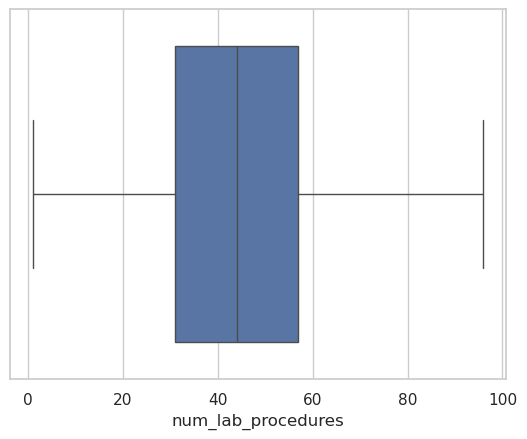

In [7]:
sns.boxplot(x=df['num_lab_procedures'])
plt.show()

In [6]:
Q1 = df['num_lab_procedures'].quantile(0.25)
Q3 = df['num_lab_procedures'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

# Clip upper outliers
df['num_lab_procedures'] = df['num_lab_procedures'].clip(upper=upper_bound)

## 🎯 Target Variable Analysis

In [ ]:
# Analyze target variable (e.g., 'readmitted')
df['readmitted'].value_counts()

In [ ]:
# Optional: Convert to binary classification if needed
df['readmitted_binary'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)
df['readmitted_binary'].value_counts(normalize=True)

### 📊 Visualizing Target Variable Distribution
Bar plots to visualize the class distribution of the `readmitted` variable.

In [ ]:
# Visualize missing values (if any are NaN)
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [ ]:
# Plot top 10 most common admission types
plt.figure(figsize=(10, 5))
sns.countplot(y='admission_type_id', data=df, order=df['admission_type_id'].value_counts().index)
plt.title('Admission Type Distribution')
plt.xlabel('Count')
plt.ylabel('Admission Type')
plt.show()

In [ ]:
# Only keep numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Plot correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix of Numeric Features")
plt.show()

## 📊 Feature Distribution & Cleaning
- Visualize top categorical columns
- Drop or encode high-cardinality fields
- Remove columns with too many missing or meaningless values

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(y='race', data=df, order=df['race'].value_counts().index)
plt.title('Patient Race Distribution')
plt.xlabel('Count')
plt.ylabel('Race')
plt.show()

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='gender', hue='readmitted', data=df)
plt.title('Readmission by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Readmitted')
plt.show()

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(x='age', hue='readmitted', data=df, order=sorted(df['age'].unique()))
plt.title('Readmission by Age Group')
plt.xlabel('Age Range')
plt.ylabel('Count')
plt.legend(title='Readmitted')
plt.show()

In [ ]:
# Drop columns with extremely high cardinality or unclear use
df.drop(['encounter_id', 'patient_nbr'], axis=1, inplace=True)

# Optional: inspect cardinality of other fields
df.nunique().sort_values(ascending=False).head(10)

In [ ]:
df.replace("?", np.nan, inplace=True)

### ✅ Cleaning Summary
- Dropped high-cardinality identifiers: `encounter_id`, `patient_nbr`
- Dropped mostly missing or low-utility fields: `weight`, `payer_code`
- Replaced `"?"` with `NaN` and confirmed remaining missing values
- Visualized `race`, `gender`, and `age` — showing imbalance and patterns in readmission